# 11 — Ensemble Stacker Shootout

Notebook 09 already does simple averages and a 2-model grid-search blend. This one picks up there and tests 
the next layer of ensemble engineering — **classical ML stackers on top of the existing NN OOF predictions** — 
scored against the exact competition metric (macro-averaged ROC-AUC, classes with zero true positives skipped).

**Why stackers, not new architectures.** At ~0.957 single-model val AUC, the marginal LB lift from a new backbone 
is typically smaller than from learning a per-class blend over the models you already trained. Tree-based stackers 
catch effects that a flat average can't — e.g. *EffV2-S is overconfident on Wood Thrush, ConvNeXt is underconfident, 
average them with weights (0.3, 0.7) for that class only*. The grid blend in notebook 09 only handles a single 
global weight, so it can't.

**Methods compared (cheapest → most expressive):**

| Method | What it learns | Risk of overfit |
|---|---|---|
| Mean blend | Nothing — equal weights | None |
| Rank-mean blend | Rank instead of prob, equal weights | None |
| Geometric-mean blend | Equal weights in log-prob space | None |
| Optimized weighted blend | One global weight per model | Low |
| Per-class isotonic + mean | Per-class monotonic calibration | Low |
| Per-class logistic regression | Per-class linear weights | Medium |
| Per-class LightGBM | Per-class nonlinear interactions | Higher — needs nested CV |

**Methodology note on leakage.** Base-model OOF predictions are out-of-fold *for the base models*, not for a stacker 
fit on top. Any stacker with capacity (LR, GBM) needs a held-out split or nested CV; otherwise its reported AUC 
is optimistic. This notebook uses a held-out 30% file split for stacker fitting + evaluation. The zero-parameter 
blends (mean, rank-mean, gmean) are evaluated on the full OOF set and don't have this problem.


## 0 — Setup

In [14]:
import os, sys, json, glob, warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

# LightGBM is optional — if missing, the GBM stacker section is skipped
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('lightgbm not installed — GBM stacker section will be skipped. `pip install lightgbm` to enable.')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')

RNG = np.random.default_rng(42)


## 1 — Competition metric

From the Kaggle metric page: per-class binary ROC-AUC, **classes with zero positive labels are skipped**, and the 
remaining per-class AUCs are averaged. `sklearn.metrics.roc_auc_score(..., average='macro')` would raise on the 
zero-positive classes, so the filter is implemented manually.


In [2]:
def macro_auc_skip_empty(y_true, y_pred):
    """
    y_true: (N, C) binary labels
    y_pred: (N, C) probability scores
    Returns: float, mean of per-class AUC over classes with at least one positive AND one negative.
    """
    aucs = []
    n_skipped = 0
    for c in range(y_true.shape[1]):
        pos = y_true[:, c].sum()
        if pos == 0 or pos == len(y_true):
            n_skipped += 1
            continue
        aucs.append(roc_auc_score(y_true[:, c], y_pred[:, c]))
    return float(np.mean(aucs)) if aucs else float('nan'), n_skipped


def per_class_auc(y_true, y_pred):
    """Same as above but returns the per-class array (NaN for skipped classes)."""
    out = np.full(y_true.shape[1], np.nan)
    for c in range(y_true.shape[1]):
        pos = y_true[:, c].sum()
        if 0 < pos < len(y_true):
            out[c] = roc_auc_score(y_true[:, c], y_pred[:, c])
    return out


# Sanity check on a synthetic case where two classes have zero positives
_y = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [1, 0, 0, 0], [0, 1, 0, 0]])
_p = np.array([[.9, .1, .5, .5], [.1, .9, .5, .5], [.8, .2, .5, .5], [.2, .8, .5, .5]])
auc, skipped = macro_auc_skip_empty(_y, _p)
print(f'sanity check: macro_auc={auc:.4f} (expected 1.0), skipped={skipped} (expected 2)')
assert abs(auc - 1.0) < 1e-9 and skipped == 2


sanity check: macro_auc=1.0000 (expected 1.0), skipped=2 (expected 2)


## 2 — Load OOF predictions

Tries to load real OOF preds from your `experiments/` tree. If not found (e.g. running this notebook on a laptop 
without access to your training cluster), falls back to synthetic data so the rest of the notebook still runs. 
**Run on your real OOFs to get meaningful numbers.**

Edit `MODELS` to point at the experiments you actually want to blend. The aggregation pattern matches notebook 09: 
concatenate `oof_preds.csv` from all five fold subdirectories.


In [3]:
META_CSV = ROOT / 'data' / 'raw' / 'train.csv'
EXP_DIR  = ROOT / 'experiments'

# Update to match the experiments you want to blend.
MODELS = {
    'effb0':       'baseline_effb0/baseline_effb0',
    'effv2s':      'effv2s_finetune/effv2s_finetune',
    'convnext':    'sed_finetune/sed_finetune',
    'seresnext':   'seresnext_finetune/seresnext_finetune',
    'effv2s_focal': 'effvs2_focal/effv2s_focal',   # outer dir has the typo (vs2), inner subdirs don't (v2s)
}
N_FOLDS = 5


def load_oof(base_pattern, n_folds=N_FOLDS):
    """Concatenate per-fold OOF CSVs. Returns None if any fold missing."""
    parts = []
    for f in range(n_folds):
        # Try a couple naming patterns used across the repo
        for pat in [f'{base_pattern}_fold{f}/oof_preds.csv',
                    f'{base_pattern}/fold{f}/oof_preds.csv']:
            p = EXP_DIR / pat
            if p.exists():
                parts.append(pd.read_csv(p))
                break
        else:
            return None
    return pd.concat(parts, ignore_index=True)


loaded = {}
for name, pattern in MODELS.items():
    df = load_oof(pattern)
    if df is not None:
        loaded[name] = df
        print(f'  loaded {name:<14} {len(df):>6} rows  {df.shape[1]-1} species cols')
    else:
        print(f'  MISSING {name} — pattern {pattern!r} did not resolve')

USING_SYNTHETIC = len(loaded) < 2
if USING_SYNTHETIC:
    print('\n--- Falling back to synthetic data so the rest of the notebook runs. ---')


  loaded effb0           35549 rows  468 species cols
  loaded effv2s          35549 rows  234 species cols
  loaded convnext        35549 rows  234 species cols
  loaded seresnext       35549 rows  234 species cols
  loaded effv2s_focal    35549 rows  234 species cols


In [4]:
# Build the canonical (y_true, {model: y_pred}) tensors used by the rest of the notebook.
# Real path: diagnose, reconcile, and align all loaded models on a canonical species set.
# Drops models that can't be reconciled rather than crashing — the rest of the notebook
# is happy with any number of models >= 2.

from collections import Counter


def _diagnose_cols(loaded):
    print('Per-model column samples:')
    for name, df in loaded.items():
        cols = [c for c in df.columns if c != 'filename']
        n = len(cols)
        if n <= 6:
            print(f'  {name:<14} ({n} cols): {cols}')
        else:
            mid = n // 2
            print(f'  {name:<14} ({n} cols)  first3={cols[:3]}  '
                  f'mid3={cols[mid-1:mid+2]}  last3={cols[-3:]}')


def _reconcile(name, cols, canonical_set):
    """
    Map this model's column list to canonical_set. Returns (keep_cols, msg) where
    keep_cols is the original-name subset to retain (all in canonical_set), or
    (None, msg) if the model can't be safely reconciled.
    """
    cols = list(cols)
    cn = len(canonical_set)

    # 0) already canonical
    if set(cols) == canonical_set:
        return cols, 'matches canonical'

    # 1) superset — drop the extras
    if canonical_set.issubset(cols):
        keep = [c for c in cols if c in canonical_set]
        extras = [c for c in cols if c not in canonical_set]
        return keep, f'dropped {len(extras)} extras (e.g. {extras[:3]})'

    # 2) exactly 2x AND first half is canonical (dual-head exported as [pool_block, max_block])
    if len(cols) == 2 * cn:
        first_half, second_half = cols[:cn], cols[cn:]
        if set(first_half) == canonical_set:
            return first_half, f'2x cols — took first {cn}, discarded second'
        if set(second_half) == canonical_set:
            return second_half, f'2x cols — took second {cn}, discarded first'
        # 2x where halves are identical (pandas didn't dedupe e.g. via index_col load)
        if first_half == second_half:
            return _reconcile(name, first_half, canonical_set)

    # 3) integer indices — can't map to species without external info
    if all(str(c).lstrip('-').isdigit() for c in cols[:5]):
        return None, (f'columns look like integer indices ({cols[:3]}..{cols[-3:]}). '
                      f'Re-export with species code headers.')

    # 4) unrecognized layout
    overlap = len(set(cols) & canonical_set)
    return None, (f'{len(cols)} cols, only {overlap} overlap with canonical ({cn}). '
                  f'Sample of non-overlapping: '
                  f'{[c for c in cols if c not in canonical_set][:5]}')


if not USING_SYNTHETIC:
    meta = pd.read_csv(META_CSV)
    common_files = set.intersection(*(set(df['filename']) for df in loaded.values()))
    print(f'Common files across {len(loaded)} models: {len(common_files)}\n')

    _diagnose_cols(loaded)
    print()

    # Canonical = the column set held by the most models (ties broken by first occurrence).
    # In the typical case (4 models with 234 cols, 1 model with a weird 468), this picks
    # the 234-col set.
    set_counts = Counter()
    for df in loaded.values():
        set_counts[frozenset(c for c in df.columns if c != 'filename')] += 1
    canonical_frozen, votes = set_counts.most_common(1)[0]
    canonical_set = set(canonical_frozen)
    species_cols = sorted(canonical_set)
    print(f'Canonical species set: {len(species_cols)} cols  '
          f'(held by {votes}/{len(loaded)} models)\n')

    aligned, dropped = {}, []
    for name, df in loaded.items():
        d = df[df['filename'].isin(common_files)].sort_values('filename').reset_index(drop=True)
        cols = [c for c in d.columns if c != 'filename']
        if set(cols) == canonical_set:
            aligned[name] = d
            continue
        keep, msg = _reconcile(name, cols, canonical_set)
        if keep is None:
            print(f'  DROP  {name}: {msg}')
            dropped.append(name)
        else:
            print(f'  FIX   {name}: {msg}')
            aligned[name] = d[['filename'] + keep]

    if dropped:
        print(f'\nProceeding with {len(aligned)}/{len(loaded)} models. Dropped: {dropped}')
    if len(aligned) < 2:
        raise RuntimeError(
            f'Only {len(aligned)} model(s) survived reconciliation — need at least 2 to '
            f'compare blends. See the diagnostic above and re-export the dropped OOFs.')

    filenames = aligned[next(iter(aligned))]['filename'].values
    merged = pd.DataFrame({'filename': filenames}).merge(
        meta[['filename', 'primary_label']], on='filename', how='left')

    # Multi-hot label matrix from primary_label only.
    # NOTE: this matches notebook 09; if you want secondary_labels included,
    # extend here, but evaluate consistently.
    y_true = np.zeros((len(filenames), len(species_cols)), dtype=np.float32)
    for i, sp in enumerate(species_cols):
        y_true[:, i] = (merged['primary_label'] == sp).astype(float)

    # `aligned[name][species_cols]` reorders to canonical species order
    preds = {name: aligned[name][species_cols].values.astype(np.float32) for name in aligned}

else:
    # Synthetic: 6000 samples, 234 classes, 5 base models with shared signal + per-model noise.
    N, C = 6000, 234
    species_cols = [f'sp_{i:03d}' for i in range(C)]
    primary = RNG.integers(0, C, size=N)
    y_true = np.zeros((N, C), dtype=np.float32)
    y_true[np.arange(N), primary] = 1.0
    base_logit = RNG.normal(0, 0.5, size=(N, C)).astype(np.float32)
    base_logit[np.arange(N), primary] += RNG.normal(2.5, 0.5, size=N).astype(np.float32)
    model_names = ['effb0', 'effv2s', 'convnext', 'seresnext', 'effv2s_focal']
    preds = {}
    for i, m in enumerate(model_names):
        noise = RNG.normal(0, 0.6 + 0.05 * i, size=base_logit.shape).astype(np.float32)
        class_bias = RNG.normal(0, 0.3, size=C).astype(np.float32)
        logit = base_logit + noise + class_bias
        preds[m] = 1 / (1 + np.exp(-logit))
    print(f'synthetic: N={N} samples, C={C} classes, {len(preds)} models')

print(f'\nshapes  y_true: {y_true.shape}  preds[*]: {next(iter(preds.values())).shape}')
print(f'positives per class:  min={y_true.sum(0).min():.0f}  '
      f'median={int(np.median(y_true.sum(0)))}  max={y_true.sum(0).max():.0f}')
print(f'classes with 0 positives: {int((y_true.sum(0)==0).sum())} (will be skipped by metric)')

Common files across 5 models: 35549

Per-model column samples:
  effb0          (468 cols)  first3=['true_1161364', 'pred_1161364', 'true_116570']  mid3=['pred_gilhum1', 'true_giwrai1', 'pred_giwrai1']  last3=['pred_yehcar1', 'true_yeofly1', 'pred_yeofly1']
  effv2s         (234 cols)  first3=['1161364', '116570', '1176823']  mid3=['gilhum1', 'giwrai1', 'glteme1']  last3=['yecpar', 'yehcar1', 'yeofly1']
  convnext       (234 cols)  first3=['1161364', '116570', '1176823']  mid3=['gilhum1', 'giwrai1', 'glteme1']  last3=['yecpar', 'yehcar1', 'yeofly1']
  seresnext      (234 cols)  first3=['1161364', '116570', '1176823']  mid3=['gilhum1', 'giwrai1', 'glteme1']  last3=['yecpar', 'yehcar1', 'yeofly1']
  effv2s_focal   (234 cols)  first3=['1161364', '116570', '1176823']  mid3=['gilhum1', 'giwrai1', 'glteme1']  last3=['yecpar', 'yehcar1', 'yeofly1']

Canonical species set: 234 cols  (held by 4/5 models)

  DROP  effb0: 468 cols, only 0 overlap with canonical (234). Sample of non-overlapping: [

## 3 — Baselines: best single model and parameter-free blends

These are scored on the full OOF set — no leakage risk because they have zero learned parameters.


In [5]:
def rank_normalize(p):
    """Per-column rank to [0, 1]. Robust to per-model probability calibration differences."""
    out = np.zeros_like(p, dtype=np.float64)
    for c in range(p.shape[1]):
        out[:, c] = rankdata(p[:, c]) / len(p)
    return out


results = []

# Per-model singles
for name, p in preds.items():
    auc, _ = macro_auc_skip_empty(y_true, p)
    results.append({'method': f'single: {name}', 'group': 'single', 'macro_auc': auc})

model_names = list(preds.keys())
P = np.stack([preds[m] for m in model_names], axis=0)   # (M, N, C)

# Mean of probabilities
auc, _ = macro_auc_skip_empty(y_true, P.mean(axis=0))
results.append({'method': 'mean (probs)', 'group': 'free blend', 'macro_auc': auc})

# Mean of ranks
P_rank = np.stack([rank_normalize(preds[m]) for m in model_names], axis=0)
auc, _ = macro_auc_skip_empty(y_true, P_rank.mean(axis=0))
results.append({'method': 'mean (ranks)', 'group': 'free blend', 'macro_auc': auc})

# Geometric mean of probs
EPS = 1e-7
auc, _ = macro_auc_skip_empty(y_true, np.exp(np.log(np.clip(P, EPS, 1-EPS)).mean(axis=0)))
results.append({'method': 'geomean (probs)', 'group': 'free blend', 'macro_auc': auc})

pd.DataFrame(results).round({'macro_auc': 4})


,method,group,macro_auc
0,single: effv2s,single,0.9569
1,single: convnext,single,0.9636
2,single: seresnext,single,0.9504
3,single: effv2s_focal,single,0.9514
4,mean (probs),free blend,0.9668
5,mean (ranks),free blend,0.9638
6,geomean (probs),free blend,0.9665


**What to look for.** If `mean (ranks)` beats `mean (probs)` by more than ~0.001, the base models are mis-calibrated 
relative to each other and rank averaging is a free win. This shows up most when models were trained with different 
losses (e.g. BCE vs focal) or different label-smoothing settings. Geometric mean tends to behave like prob mean here 
but punishes any single confidently-wrong model more harshly.


## 4 — Held-out split for learned stackers

Everything from here on has tunable parameters, so it needs a held-out split. We split *files* (not rows of the 
label matrix — same thing here, but worth being explicit), 70/30 stratified loosely on whether the sample has any 
positive label. Stackers are fit on the 70%, scored on the 30%.


In [6]:
rng = np.random.default_rng(42)
N = y_true.shape[0]
perm = rng.permutation(N)
split = int(0.7 * N)
train_idx, val_idx = perm[:split], perm[split:]

y_tr, y_va = y_true[train_idx], y_true[val_idx]
P_tr = P[:, train_idx, :]    # (M, N_tr, C)
P_va = P[:, val_idx, :]      # (M, N_va, C)

# Re-evaluate the parameter-free blends on the val split for fair comparison with the learned ones below.
free_val = {}
free_val['mean (probs)'],   _ = macro_auc_skip_empty(y_va, P_va.mean(0))
free_val['mean (ranks)'],   _ = macro_auc_skip_empty(y_va, np.stack([rank_normalize(P_va[m]) for m in range(P_va.shape[0])]).mean(0))
free_val['geomean (probs)'], _ = macro_auc_skip_empty(y_va, np.exp(np.log(np.clip(P_va, EPS, 1-EPS)).mean(0)))
free_val['best single'] = max(
    macro_auc_skip_empty(y_va, P_va[m])[0] for m in range(P_va.shape[0]))

for k, v in free_val.items():
    print(f'  {k:<18} {v:.4f}')
print(f'\ntrain/val split: {len(train_idx)} / {len(val_idx)} samples')


  mean (probs)       0.9750
  mean (ranks)       0.9745
  geomean (probs)    0.9759
  best single        0.9707

train/val split: 24884 / 10665 samples


## 5 — Optimized weighted blend (one global weight per model)

Notebook 09 does a 0.1-step grid search on 2 models. Scipy's Nelder-Mead handles arbitrary M models in seconds. 
Weights are constrained to the simplex (non-negative, sum to 1) via softmax reparameterization.


In [7]:
def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()


def weighted_blend(P_stack, weights):
    # P_stack: (M, N, C); weights: (M,)
    return (P_stack * weights[:, None, None]).sum(axis=0)


M = P_tr.shape[0]

def neg_macro_auc(theta, P_stack, y):
    w = softmax(theta)
    blend = weighted_blend(P_stack, w)
    auc, _ = macro_auc_skip_empty(y, blend)
    return -auc


# Optimize on TRAIN, evaluate on VAL
theta0 = np.zeros(M)    # softmax(0) = uniform
res = minimize(neg_macro_auc, theta0, args=(P_tr, y_tr),
               method='Nelder-Mead', options={'xatol': 1e-3, 'fatol': 1e-5, 'maxiter': 400})
w_opt = softmax(res.x)

auc_train = -res.fun
auc_val,_ = macro_auc_skip_empty(y_va, weighted_blend(P_va, w_opt))

print('Optimized weights (sum to 1):')
for name, w in zip(model_names, w_opt):
    print(f'  {name:<14} {w:.3f}')
print(f'\nmacro AUC  train: {auc_train:.4f}   val: {auc_val:.4f}')
print(f'gap:                 {auc_train - auc_val:+.4f}    (large positive gap ⇒ overfit)')


Optimized weights (sum to 1):
  effv2s         0.250
  convnext       0.250
  seresnext      0.250
  effv2s_focal   0.250

macro AUC  train: 0.9675   val: 0.9750
gap:                 -0.0075    (large positive gap ⇒ overfit)


## 6 — Per-class isotonic calibration, then mean-blend

Each base model is recalibrated *per species* with isotonic regression on the train split, then the calibrated 
probabilities are mean-blended on val. This is non-parametric, monotonic, and almost can't hurt — typically the 
best 'safe' improvement over a flat mean when models were trained with different losses.

Skips classes with no train-split positives; for those, falls back to the raw probability.


In [8]:
def isotonic_calibrate(P_stack_tr, y_tr_, P_stack_va):
    """Per-(model, class) isotonic. Returns calibrated val predictions, same shape as P_stack_va."""
    M, _, C = P_stack_tr.shape
    out = P_stack_va.copy()
    for m in range(M):
        for c in range(C):
            yt = y_tr_[:, c]
            if yt.sum() < 2 or yt.sum() > len(yt) - 2:
                continue   # fall through to raw
            iso = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
            iso.fit(P_stack_tr[m, :, c], yt)
            out[m, :, c] = iso.predict(P_stack_va[m, :, c])
    return out


P_va_calib = isotonic_calibrate(P_tr, y_tr, P_va)
auc_iso, _ = macro_auc_skip_empty(y_va, P_va_calib.mean(0))
print(f'per-class isotonic + mean   val macro AUC: {auc_iso:.4f}')


per-class isotonic + mean   val macro AUC: 0.9753


## 7 — Per-class logistic regression stacker

For each species: fit a tiny binary logistic regression where the inputs are the M base-model probabilities for 
that species (no other features). Outputs are the calibrated stacked probability. M coefficients per class — about 
as low-capacity as a learned stacker can get.

Practical note: classes with very few positives (single digits) get unstable coefficients. Fall back to a flat mean 
for those.


In [9]:
def per_class_logreg(P_stack_tr, y_tr_, P_stack_va, min_pos=10):
    M, _, C = P_stack_tr.shape
    out = np.zeros_like(P_stack_va[0])    # (N_va, C)
    fallback_count = 0
    for c in range(C):
        yt = y_tr_[:, c]
        if yt.sum() < min_pos:
            out[:, c] = P_stack_va[:, :, c].mean(0)
            fallback_count += 1
            continue
        X_tr = P_stack_tr[:, :, c].T    # (N_tr, M)
        X_va = P_stack_va[:, :, c].T    # (N_va, M)
        clf = LogisticRegression(max_iter=200, C=1.0)
        clf.fit(X_tr, yt)
        out[:, c] = clf.predict_proba(X_va)[:, 1]
    return out, fallback_count


blend_lr, n_fb = per_class_logreg(P_tr, y_tr, P_va)
auc_lr, _ = macro_auc_skip_empty(y_va, blend_lr)
print(f'per-class logistic regression   val macro AUC: {auc_lr:.4f}   '
      f'(fell back to mean on {n_fb} rare classes)')


per-class logistic regression   val macro AUC: 0.9750   (fell back to mean on 60 rare classes)


## 8 — Per-class LightGBM stacker

Same per-class structure as logistic regression but with a small GBM. Captures interactions like *if EffV2-S says 
high but ConvNeXt says low, trust EffV2-S half as much* — which a linear model can't represent. More expressive, 
but the per-class AUC delta is the metric of record so we use `objective='binary'` with early stopping on the 
in-class binary loss as a proxy.

This is the 'ensemble method' classical-ML answer to your question. If it doesn't beat per-class LR by a clear 
margin (~0.001+), the linear stacker is the better deploy choice — same accuracy, dramatically simpler to ship.


In [10]:
def per_class_lgbm(P_stack_tr, y_tr_, P_stack_va, min_pos=10,
                   num_leaves=15, n_estimators=80, learning_rate=0.05):
    if not HAS_LGB:
        raise RuntimeError('lightgbm not installed')
    M, _, C = P_stack_tr.shape
    out = np.zeros_like(P_stack_va[0])
    fallback_count = 0
    for c in range(C):
        yt = y_tr_[:, c]
        if yt.sum() < min_pos:
            out[:, c] = P_stack_va[:, :, c].mean(0)
            fallback_count += 1
            continue
        X_tr = P_stack_tr[:, :, c].T
        X_va = P_stack_va[:, :, c].T
        clf = lgb.LGBMClassifier(
            num_leaves=num_leaves,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            min_data_in_leaf=5,
            verbosity=-1,
        )
        clf.fit(X_tr, yt)
        out[:, c] = clf.predict_proba(X_va)[:, 1]
    return out, fallback_count


if HAS_LGB:
    blend_gbm, n_fb = per_class_lgbm(P_tr, y_tr, P_va)
    auc_gbm, _ = macro_auc_skip_empty(y_va, blend_gbm)
    print(f'per-class LightGBM   val macro AUC: {auc_gbm:.4f}   (fell back to mean on {n_fb} rare classes)')
else:
    auc_gbm = float('nan')
    print('lightgbm not installed — skipping')


per-class LightGBM   val macro AUC: 0.9168   (fell back to mean on 60 rare classes)


## 9 — Comparison table & recommendation

All numbers below are on the held-out 30% val split, so they're directly comparable.


In [11]:
comparison = []
for k, v in free_val.items():
    comparison.append({'method': k, 'group': 'free / single', 'val_macro_auc': v})
comparison.append({'method': 'optimized weighted (Nelder-Mead)', 'group': 'global learned', 'val_macro_auc': auc_val})
comparison.append({'method': 'per-class isotonic + mean',         'group': 'per-class learned', 'val_macro_auc': auc_iso})
comparison.append({'method': 'per-class logistic regression',     'group': 'per-class learned', 'val_macro_auc': auc_lr})
if HAS_LGB:
    comparison.append({'method': 'per-class LightGBM',              'group': 'per-class learned', 'val_macro_auc': auc_gbm})

comp_df = pd.DataFrame(comparison).sort_values('val_macro_auc', ascending=False).reset_index(drop=True)
best_single = free_val['best single']
comp_df['vs_best_single'] = comp_df['val_macro_auc'] - best_single
print(comp_df.round({'val_macro_auc': 4, 'vs_best_single': 4}).to_string(index=False))


                          method             group  val_macro_auc  vs_best_single
                 geomean (probs)     free / single         0.9759          0.0052
       per-class isotonic + mean per-class learned         0.9753          0.0046
   per-class logistic regression per-class learned         0.9750          0.0044
optimized weighted (Nelder-Mead)    global learned         0.9750          0.0043
                    mean (probs)     free / single         0.9750          0.0043
                    mean (ranks)     free / single         0.9745          0.0038
                     best single     free / single         0.9707          0.0000
              per-class LightGBM per-class learned         0.9168         -0.0539


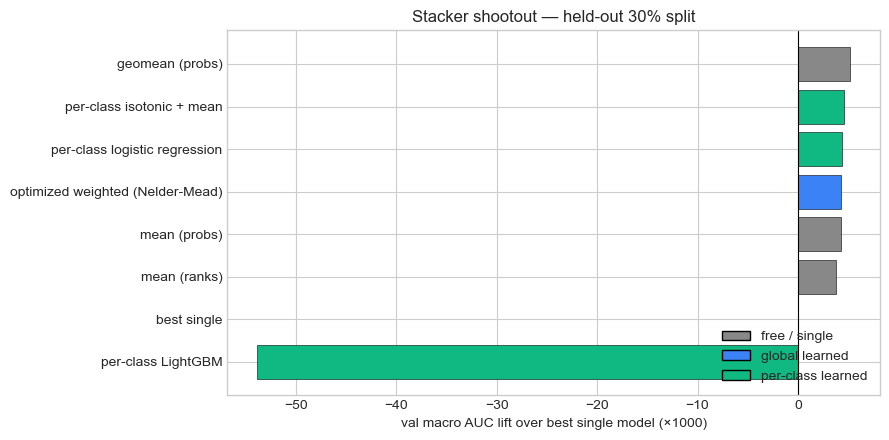

In [12]:
# Bar plot of the lift vs best single
fig, ax = plt.subplots(figsize=(9, 4.5))
df_plot = comp_df.sort_values('val_macro_auc')
colors = {'free / single': '#888', 'global learned': '#3b82f6', 'per-class learned': '#10b981'}
ax.barh(df_plot['method'], df_plot['vs_best_single'] * 1000,
        color=[colors[g] for g in df_plot['group']], edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('val macro AUC lift over best single model (×1000)')
ax.set_title('Stacker shootout — held-out 30% split')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, edgecolor='black', label=g) for g, c in colors.items()],
          loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()


## 10 — Diversity check (why some blends help and others don't)

If two base models correlate above ~0.97 on OOF, a stacker can't extract much from their combination — the second 
model contributes redundant signal. Pairwise OOF correlation of the per-sample max-class probability is a quick 
diversity proxy. Pairs in the green zone (<0.92) are where a stacker tends to pay off.


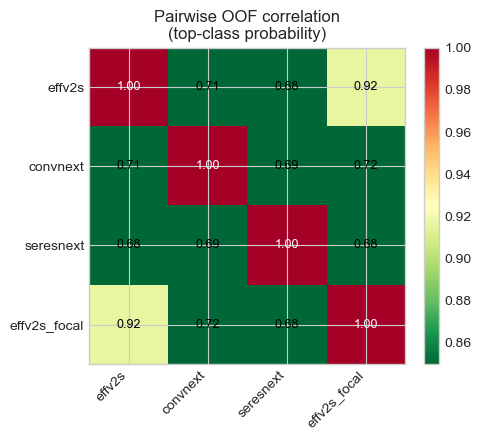

Greedy forward selection (mean blend):
  step 1  add convnext        AUC=0.9707
  step 2  add effv2s          AUC=0.9761  (+0.0054)
  step 3  add seresnext       AUC=0.9758  (-0.0003)
  step 4  add effv2s_focal    AUC=0.9750  (-0.0008)


In [13]:
# Use per-sample top-class probability as the diversity signal — captures "where the model thinks the bird is"
top_probs = np.stack([preds[m].max(axis=1) for m in model_names], axis=1)   # (N, M)
corr = np.corrcoef(top_probs.T)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, vmin=0.85, vmax=1.0, cmap='RdYlGn_r')
ax.set_xticks(range(len(model_names))); ax.set_yticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=45, ha='right'); ax.set_yticklabels(model_names)
for i in range(len(model_names)):
    for j in range(len(model_names)):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                color='white' if corr[i,j] > 0.95 else 'black', fontsize=9)
ax.set_title('Pairwise OOF correlation\n(top-class probability)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# Greedy forward selection: start with best single, add the model that gives biggest val-AUC bump under mean blend
remaining = set(model_names)
selected = [max(model_names, key=lambda m: macro_auc_skip_empty(y_va, P_va[model_names.index(m)])[0])]
remaining.discard(selected[0])
history = [(selected[0], macro_auc_skip_empty(y_va, P_va[model_names.index(selected[0])])[0])]
while remaining:
    best, best_auc = None, -np.inf
    for m in remaining:
        cur = selected + [m]
        idx = [model_names.index(x) for x in cur]
        auc, _ = macro_auc_skip_empty(y_va, P_va[idx].mean(0))
        if auc > best_auc:
            best, best_auc = m, auc
    selected.append(best); remaining.discard(best)
    history.append((best, best_auc))

print('Greedy forward selection (mean blend):')
for i, (m, a) in enumerate(history):
    delta = '' if i == 0 else f'  ({a - history[i-1][1]:+.4f})'
    print(f'  step {i+1}  add {m:<14}  AUC={a:.4f}{delta}')


## 11 — How to read these results

**Promote a stacker to your submission only if:**

1. **The val lift is ≥ 0.001 macro AUC** over the best free blend (`mean`, `mean (ranks)`, or `geomean`). Anything 
smaller is split-noise. If you want a tighter check, repeat sections 4-9 with `np.random.default_rng(123)` and 
`(...456)` and confirm the winner is stable across all three seeds.
2. **The train-val gap is small.** A 0.997 train AUC and 0.954 val AUC for the LightGBM stacker means it memorized 
the train split. Drop `n_estimators` and re-test, or fall back to logistic regression.
3. **The simplest method that wins, wins.** If `mean (ranks)` is within 0.0005 of LightGBM, ship `mean (ranks)`. 
It's one line of code in the inference notebook and has no parameters to drift.

**On the original question — neural networks vs ensemble methods.** Tree models on raw spectrograms aren't 
competitive with CNNs (no spatial inductive bias), so they're not a *replacement* for your NN backbone. But as 
**stage-2 stackers on top of NN OOFs** (sections 7-8), they're standard practice in audio comps and almost always 
earn back their complexity at this stage of a competition. The diversity check in section 10 tells you whether 
you're hitting the ceiling because your base models agree too much — if so, the highest-leverage move is training 
*one more* model from a different family before stacking, not stacking harder on what you have.

**On the previous notebook (10).** A small clarification on what it actually showed: `RUN_QUICK_FIT` stayed `False`, 
so the five new architectures were profiled but never trained. The 'no candidate beats anchor' message in section 5 
of notebook 10 was triggered by NaN comparisons against the candidate val_auc column, not by measured failures. If 
this notebook (11) shows the stackers also plateauing, *then* it's worth flipping `RUN_QUICK_FIT = True` in 10 and 
investing the GPU hours — particularly on `eca_nfnet_l0`, the most BirdCLEF-pedigreed candidate in the roster.
